# Lab: Naive Bayes Classification

*In this lab, we will apply Naive Bayes (NB) models using scikit-learn to classify iris species, continuing the consistent methodology established in previous labs. This allows direct comparison of model performance and interpretation across multiple approaches ([baseline](./07_multi_class_classification_lab.ipynb), [decision tree](./10_decision_trees_lab.ipynb), [SVM](./16_support_vector_machines_lab.ipynb), [k-NN](./19_knn_lab.ipynb), and now Naive Bayes), all using the same data preparation and analytic context.*

---

> ### 📝 1–5. Previous Stages Report (Summary)
> - **Business Context:** The core business challenge is to automate accurate iris species identification for a botanical institute, improving upon the slow, error-prone process of manual classification.
> - **Business Problem:** Rapid and reliable classification, especially of the valuable *Iris-virginica*, is required to support research and operational efficiency.
> - **Analytic Approach:** We have defined the problem as supervised multi-class classification. Previous labs applied softmax regression, decision tree, SVM, and k-NN models, evaluating performance with stratified train-test splits and standard metrics (accuracy, precision, recall, F1, confusion matrix).
> - **Data Requirements & Collection:** The classic scikit-learn iris dataset (four numerical features per record, three balanced species classes) was cleaned and augmented in earlier labs, and all work utilizes the same processed version. This file also contains two engineered features driven by domain knowledge and earlier EDA.
> - **Feature Engineering:** Two domain-inspired features were created:
>   - `petal_area` (`petal_length * petal_width`)
>   - `sepal_ratio` (`sepal_length / sepal_width`)
>   These, along with the original features, are available for model evaluation.
> - **Data Understanding:**  
>   - Petal-based features are especially predictive.
>   - The dataset is well-balanced and has undergone comprehensive cleaning.
>   - Engineered features have proven useful for several prior classifiers.
>   - Previous models consistently achieved high accuracy (typically >90%), with most confusion occurring between the versicolor and virginica classes.
> - **Transition to Naive Bayes Modeling:**  This lab introduces Naive Bayes, specifically GaussianNB (well-suited for the continuous features in iris). Comparison with earlier models will highlight the impact of model assumptions—especially feature independence and normality—on classification performance.

---

## Stage 6: Data Preparation

As in prior labs, we begin by importing the necessary libraries and configuring plotting and analysis preferences.

In [11]:
# Import libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.naive_bayes import GaussianNB
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix, ConfusionMatrixDisplay

# Configurations
plt.style.use("fivethirtyeight")
sns.set_theme(style="white", palette="colorblind")

Next, we load the standardized and feature-engineered iris dataset for analysis:

In [12]:
# Load the cleaned and engineered iris dataset
iris_df = pd.read_parquet("../data/processed/iris_multi-class_processed_v1.parquet")
iris_df.sample(5)

,sepal_length,sepal_width,petal_length,petal_width,target,class_name,petal_area,sepal_ratio
52,6.9,3.1,4.9,1.5,1,versicolor,7.35,2.225806
73,6.1,2.8,4.7,1.2,1,versicolor,5.64,2.178571
26,5.0,3.4,1.6,0.4,0,setosa,0.64,1.470588
141,6.9,3.1,5.1,2.3,2,virginica,11.73,2.225806
71,6.1,2.8,4.0,1.3,1,versicolor,5.20,2.178571


For simplicity and to highlight the impact of feature engineering, we'll use only the two engineered features as predictors.

Let's create the feature matrix and the target vector, and split them. Scaling is not required for Naive Bayes (GaussianNB), as class-conditional likelihoods are modeled independently for each feature.

In [13]:
X = iris_df[["petal_area", "sepal_ratio"]]
y = iris_df["target"]

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)


---

> ### 📝 6. Data Preparation Report (Summary)
> - The standardized and feature-engineered iris dataset was loaded from previous labs to ensure reproducibility and comparability.
> - For this Naive Bayes lab, **only the two engineered features** were selected as predictors:
>   - `petal_area` — capturing overall petal size,
>   - `sepal_ratio` — capturing the relation between sepal length and width.
>   This focus allows us to directly assess the value of domain-informed feature engineering.
> - The target variable remains the original multi-class species label (`target`).
> - Data was split into training and test sets (80/20) using stratified sampling to maintain class balance for robust and fair evaluation.
> - **No feature scaling was performed.** Unlike models such as KNN or SVM, Gaussian Naive Bayes does *not* require predictors to be on the same scale, as it models each feature’s distribution independently for each class.
> - The train and test sets are now ready for Gaussian Naive Bayes model training and evaluation.

---

## Stage 7: Modeling

In [14]:
# Create and fit the model
clf = GaussianNB().fit(X_train, y_train)


---

> ### 📝 7. Modeling Report (Summary)
> - A **Gaussian Naive Bayes (GaussianNB)** classifier from scikit-learn was selected for this stage, due to its efficiency and suitability for continuous feature data like the engineered predictors in this lab.
> - The model was configured with default parameters, with no need for hyperparameter selection or special settings.
> - Training was completed in a single step using the two engineered features (`petal_area` and `sepal_ratio`) and the stratified training set. GaussianNB directly estimates the mean and variance of each predictor per class to model class-conditional probability distributions.
> - No advanced model tuning, cross-validation, or resampling was performed at this stage, in accordance with the current module objectives. Parameter search and best practices will be explored in advanced stages.
> - The trained Naive Bayes model is now ready for predictive evaluation on the hold-out test set, using the same comparison metrics established in prior labs.

---

## Stage 8: Evaluation

In [15]:
# Predict on the test set
y_pred = clf.predict(X_test)

In [16]:
# Compute standard multi-class metrics
accuracy = accuracy_score(y_test, y_pred)
precision = precision_score(y_test, y_pred, average="weighted")
recall = recall_score(y_test, y_pred, average="weighted")
f1 = f1_score(y_test, y_pred, average="weighted")

print("Evaluation Metrics on Test Set:")
print(f"  Accuracy : {accuracy:.4f}")
print(f"  Precision: {precision:.4f}")
print(f"  Recall   : {recall:.4f}")
print(f"  F1-Score : {f1:.4f}")

Evaluation Metrics on Test Set:
  Accuracy : 0.9000
  Precision: 0.9061
  Recall   : 0.9000
  F1-Score : 0.9015


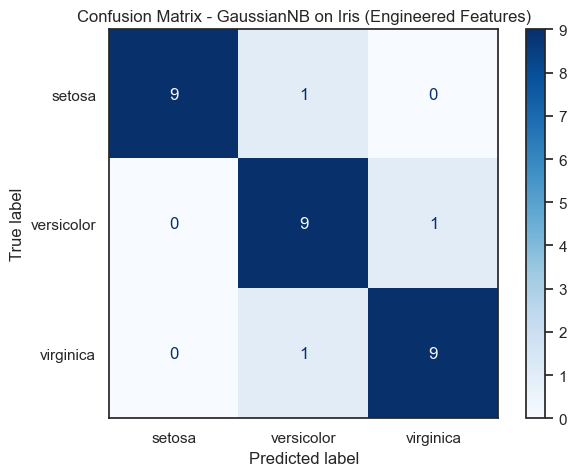

In [17]:
# Confusion matrix
cm = confusion_matrix(y_test, y_pred)
disp = ConfusionMatrixDisplay(cm, display_labels=['setosa', 'versicolor', 'virginica'])
disp.plot(cmap="Blues")
plt.title("Confusion Matrix - GaussianNB on Iris (Engineered Features)")
plt.show()


---

> ### 📝 8. Evaluation Report (Summary)
> - The trained Gaussian Naive Bayes model was evaluated on the hold-out test set using standard multi-class metrics: accuracy, precision, recall, and F1-score.
> - **Evaluation Results:** Accuracy: 90.00%. Precision: 90.61%. Recall: 90.00%, F1-Score: 90.15%.
> - **Confusion Matrix Interpretation:**
>     - The model achieved perfect or near-perfect classification for most samples in each class.
>     - Each species (setosa, versicolor, virginica) had one misclassification, with errors mainly occurring between neighboring classes (e.g., some setosa misclassified as versicolor, and so on).
>     - No single class dominated in errors, indicating a balanced performance across classes.
> - No cross-validation or parameter tuning was performed in this stage, as per lab guidelines. These techniques will be introduced in advanced modules.
> - Overall, the Naive Bayes approach demonstrated solid performance with the engineered features, though its accuracy was slightly lower than some previous models (such as SVM and KNN). This highlights the impact of Naive Bayes’ feature independence and normality assumptions on real-world classification tasks.

---

**Next:** [Bias, Variance, and Ensemble Models Theory](./23_bias_variance_and_ensemble_models_theory.md)